In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

## 1. Loading the Data
Dataset: UCI Diabetes 130-US Hospitals (1999–2008), ~101,766 encounters, 50 columns.
Goal of this section: confirm shape, dtypes, and get a first read on what we're working with before touching anything.

In [2]:
import pandas as pd
df = pd.read_csv('C:\\Users\\yomna\\Desktop\\readmission-project\\data\\diabetic_data.csv')

print(df.shape)
df.head()


(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.sample(6)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
3550,21829710,5000193,Caucasian,Female,[70-80),?,3,1,1,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
73043,215077410,89168508,Caucasian,Male,[80-90),?,3,22,1,5,...,No,Up,No,No,No,No,No,Ch,Yes,>30
42713,131772126,23285178,Caucasian,Female,[60-70),?,1,7,7,8,...,No,Down,No,No,No,No,No,Ch,Yes,NO
87445,279273606,43505478,Caucasian,Male,[60-70),?,3,6,1,4,...,No,Down,No,No,No,No,No,Ch,Yes,<30
41634,128757198,25002045,Caucasian,Female,[70-80),?,1,3,5,5,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
10902,45663864,217638,Caucasian,Male,[60-70),?,3,18,1,3,...,No,No,No,No,No,No,No,No,No,NO


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

## Dataset Feature Dictionary - Diabetes 130-US Hospitals (1999-2008)

This dataset contains 101,766 patient encounters from 130 US hospitals, where each row is one hospital admission of a patient with a diabetes diagnosis. The main goal is usually to predict hospital readmission (often within 30 days). Below is a grouped, plain-English breakdown of every feature.



### 1. Identifiers

These don't carry medical meaning - they just uniquely identify rows/patients.

| Feature | What it means |
|---|---|
| encounter_id | Unique ID for this specific hospital visit/encounter. |
| patient_nbr | Unique ID for the patient. Note: the same patient can appear multiple times (multiple encounters), so this is key for avoiding data leakage between train/test splits. |

---

### 2. Demographics

Basic information about the patient. These are sensitive attributes - handle with care regarding bias/fairness.

| Feature | What it means |
|---|---|
| race | Patient's race: Caucasian, African American, Asian, Hispanic, or Other. Contains missing values. |
| gender | Male, Female, or Unknown/Invalid. |
| age | Age bucketed into 10-year ranges: [0-10), [10-20), ... [90-100). |
| weight | Patient weight (in pounds). Mostly missing (about 97% missing) - usually dropped or treated as an "unknown" category. |

---

### 3. Admission and Discharge Details

Describes how and why the patient entered/left the hospital. These are coded as integer IDs that map to a separate lookup table (IDS_mapping.csv), so you'll want to decode them into readable labels.

| Feature | What it means |
|---|---|
| admission_type_id | Code (1-9) for how the patient was admitted - e.g., Emergency, Urgent, Elective, Newborn, or Not Available/Unknown. |
| discharge_disposition_id | Code (1-29) for where the patient went after discharge - e.g., discharged home, transferred to another facility, expired, left against medical advice. |
| admission_source_id | Code (1-21) for where the patient came from - e.g., physician referral, emergency room, transfer from another hospital. |
| time_in_hospital | Number of days between admission and discharge (length of stay), ranges 1-14 days by design. |

---

### 4. Care Team and Setting

| Feature | What it means |
|---|---|
| payer_code | Code identifying who is paying for the treatment (e.g., insurance type, Medicare, self-pay). Has missing values. |
| medical_specialty | Specialty of the admitting physician (e.g., Cardiology, Family/GeneralPractice, InternalMedicine). Has 53% missing values. |

---

### 5. Hospital Utilization (Volume Counts)

These describe how much clinical activity happened during this specific encounter - good indicators of severity/complexity.

| Feature | What it means |
|---|---|
| num_lab_procedures | Number of lab tests performed during the encounter. |
| num_procedures | Number of non-lab procedures performed (e.g., surgeries, other interventions). |
| num_medications | Number of distinct generic medications administered during the encounter. |
| number_outpatient | Number of outpatient visits by the patient in the year before this encounter. |
| number_emergency | Number of emergency room visits by the patient in the year before this encounter. |
| number_inpatient | Number of inpatient (hospital admission) visits by the patient in the year before this encounter. |
| number_diagnoses | Total number of diagnoses entered into the system for this encounter. |

Note: these "prior visit" counts (number_outpatient, number_emergency, number_inpatient) are often strong predictors of readmission - patients with a history of frequent visits tend to come back more.

---

### 6. Diagnoses

Each encounter can log up to three diagnosis codes (ICD-9 format), ordered roughly by clinical priority.

| Feature | What it means |
|---|---|
| diag_1 | Primary (main) diagnosis code. |
| diag_2 | Secondary diagnosis code. |
| diag_3 | Additional (tertiary) diagnosis code. |

These are raw ICD-9 codes (numeric/alphanumeric strings) - commonly grouped into broader disease categories (e.g., circulatory, respiratory, diabetes-related) during preprocessing since there are hundreds of unique raw codes.

---

### 7. Diabetes-Specific Lab Results

| Feature | What it means |
|---|---|
| max_glu_serum | Result of the glucose serum test, indicating range: >200, >300, Normal, or None (test not performed). |
| A1Cresult | Result of the HbA1c test (average blood sugar over about 3 months): >7, >8, Normal, or None (test not performed). This was the key variable studied in the original research paper behind this dataset. |

---

### 8. Medication Features

For each individual diabetes drug (23 in total, listed below), there's a column showing whether the dosage was kept steady, increased, decreased, or the drug wasn't prescribed during the encounter.

Possible values for each drug column: Up (dosage increased), Down (dosage decreased), Steady (no change), No (not prescribed).

The 23 medication columns:

metformin, repaglinide, nateglinide, chlorpropamide, glimepiride, acetohexamide, glipizide, glyburide, tolbutamide, pioglitazone, rosiglitazone, acarbose, miglitol, troglitazone, tolazamide, examide, citoglipton, insulin, glyburide-metformin, glipizide-metformin, glimepiride-pioglitazone, metformin-rosiglitazone, metformin-pioglitazone

Note: many of these columns have almost no variation (e.g., examide, citoglipton are almost always "No") - worth checking value counts before using them as model features, since near-constant columns add little signal.

| Feature | What it means |
|---|---|
| change | Whether there was any change in diabetic medications (dosage or drug) during the encounter: Ch (changed) or No (no change). A summary flag across all the drug columns above. |
| diabetesMed | Whether any diabetes medication was prescribed at all during the encounter: Yes / No. |

---

### 9. Target Variable

| Feature | What it means |
|---|---|
| readmitted | Whether the patient was readmitted to the hospital: <30 (readmitted within 30 days), >30 (readmitted after 30 days), or NO (not readmitted). This is the typical prediction target, often binarized into <30 vs. everything else for the classic "30-day readmission" task. |

---

### Quick Recap - Grouping Summary

| Group | Purpose |
|---|---|
| Identifiers | Track rows/patients, not predictive |
| Demographics | Patient background (sensitive attributes) |
| Admission/Discharge | Encoded logistics of the hospital stay |
| Care team | Who treated the patient, who paid |
| Utilization counts | Encounter intensity and prior healthcare use |
| Diagnoses | What conditions were recorded |
| Lab results | Diabetes-specific test outcomes |
| Medications | Drug-by-drug dosage changes |
| Target | What you're trying to predict |

---

#### Notes for preprocessing
- weight, payer_code, and medical_specialty have heavy missingness, gonna decide whether to drop, impute, or bucket as "Missing"/"Unknown" category..
- admission_type_id, discharge_disposition_id, admission_source_id need to be joined with IDS_mapping.csv to get human-readable labels.
- diag_1/2/3 typically need grouping into higher-level ICD-9 categories to be usable (too many unique raw codes otherwise).
- Since patient_nbr repeats for patients with multiple encounters, split train/test by patient, not by row, to avoid leakage.

## 1.1. Univariate Distribution Check (Numeric Features)

This covers histograms for shape/skew and boxplots for outlier spotting, on the raw numeric columns:
time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, number_diagnoses

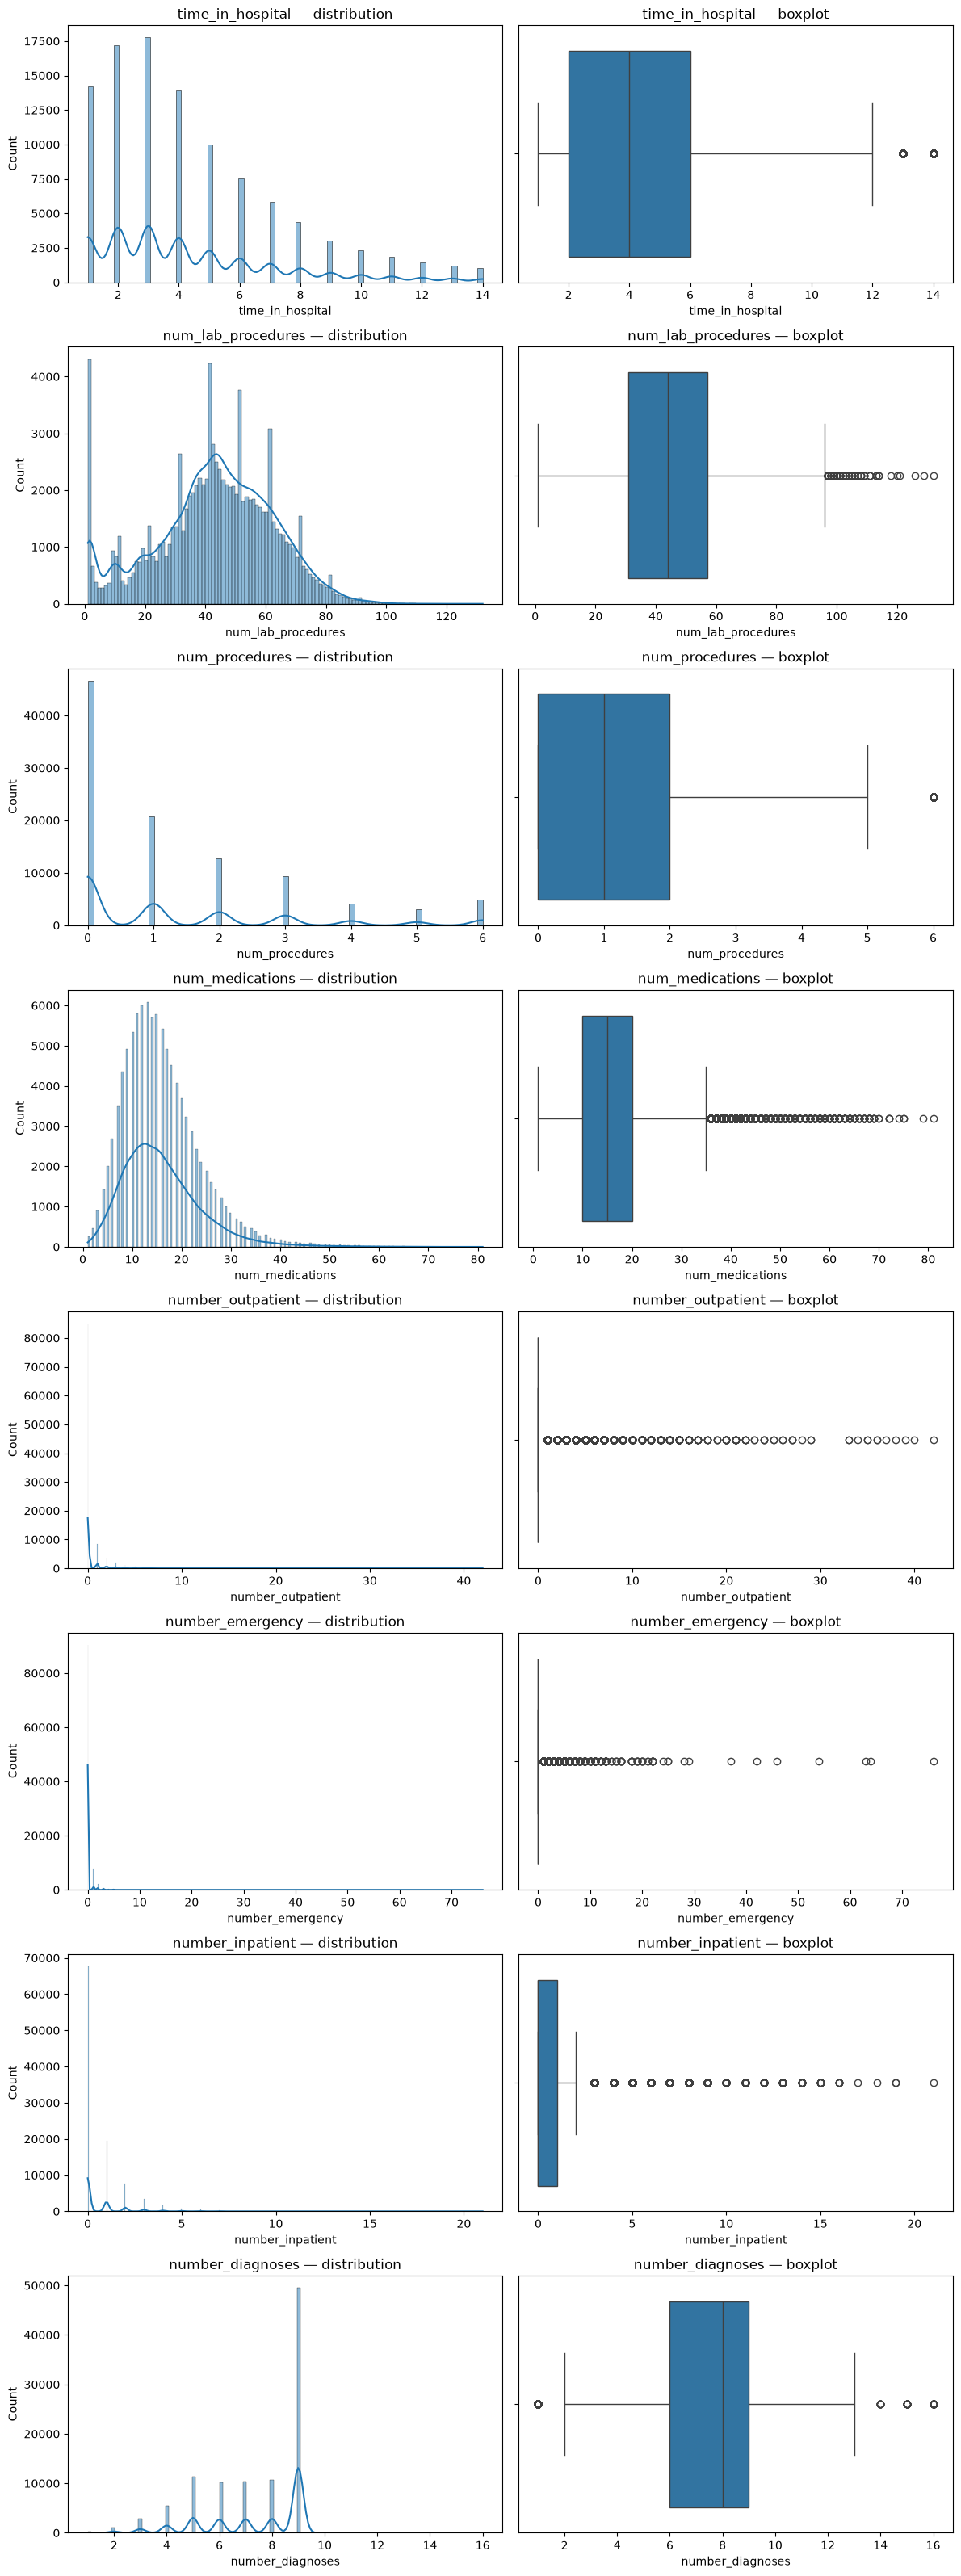

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — distribution')

    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — boxplot')

plt.tight_layout()
plt.show()

In [6]:
print(df[numeric_cols].describe().T)

                       count       mean        std  min   25%   50%   75%  \
time_in_hospital    101766.0   4.395987   2.985108  1.0   2.0   4.0   6.0   
num_lab_procedures  101766.0  43.095641  19.674362  1.0  31.0  44.0  57.0   
num_procedures      101766.0   1.339730   1.705807  0.0   0.0   1.0   2.0   
num_medications     101766.0  16.021844   8.127566  1.0  10.0  15.0  20.0   
number_outpatient   101766.0   0.369357   1.267265  0.0   0.0   0.0   0.0   
number_emergency    101766.0   0.197836   0.930472  0.0   0.0   0.0   0.0   
number_inpatient    101766.0   0.635566   1.262863  0.0   0.0   0.0   1.0   
number_diagnoses    101766.0   7.422607   1.933600  1.0   6.0   8.0   9.0   

                      max  
time_in_hospital     14.0  
num_lab_procedures  132.0  
num_procedures        6.0  
num_medications      81.0  
number_outpatient    42.0  
number_emergency     76.0  
number_inpatient     21.0  
number_diagnoses     16.0  


In [7]:
# Temporary target for this EDA check only (readmitted_binary doesn't exist yet at this point)
target_temp = (df['readmitted'] == '<30').astype(int)

for col in ['number_outpatient', 'number_emergency', 'number_inpatient']:
    threshold = df[col].quantile(0.99)
    high_group = df[df[col] >= threshold]
    rest = df[df[col] < threshold]
    high_target = target_temp[high_group.index]
    rest_target = target_temp[rest.index]
    
    print(f"--- {col} ---")
    print(f"99th pct threshold: {threshold}")
    print(f"High-value rows: {len(high_group)} | readmit rate: {high_target.mean():.3f}")
    print(f"Rest rows: {len(rest)} | readmit rate: {rest_target.mean():.3f}")
    print()

--- number_outpatient ---
99th pct threshold: 5.0
High-value rows: 1457 | readmit rate: 0.124
Rest rows: 100309 | readmit rate: 0.111

--- number_emergency ---
99th pct threshold: 3.0
High-value rows: 1664 | readmit rate: 0.249
Rest rows: 100102 | readmit rate: 0.109

--- number_inpatient ---
99th pct threshold: 6.0
High-value rows: 1204 | readmit rate: 0.398
Rest rows: 100562 | readmit rate: 0.108



**Outlier verdict - number_outpatient, number_emergency, number_inpatient:**
All three showed extreme-tail values on boxplots, but cross-checking against
readmission rate shows this tail is real signal, not noise:
- number_outpatient: high group 12.4% vs. rest 11.1% (mild difference)
- number_emergency: high group 24.9% vs. rest 10.9% (~2.3x higher)
- number_inpatient: high group 39.8% vs. rest 10.8% (~3.7x higher, strongest signal —
  consistent with number_inpatient being flagged as our top predictor in prior EDA)

Decision: no capping, clipping, or removal. These values represent genuine
high-utilizer patients and are kept as-is going into feature engineering.

## 2. Missing Values
"?" placeholders need to be converted to real NaN before we can measure missingness properly.
These are all categorical columns, so we fill missing values with an explicit "Missing" category
rather than mean/median (which only makes sense for continuous numbers).

In [8]:
#convert '?' to real NaN and measure missingness
df_clean = df.replace('?', np.nan)

missing_pct = df_clean.isnull().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

In [9]:
#duplicate rows check
print("Fully duplicate rows:", df_clean.duplicated().sum())

Fully duplicate rows: 0


In [10]:
#fill categorical missing values with "Missing"
cols_to_fill = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code', 'race']

for col in cols_to_fill:
    df_clean[col] = df_clean[col].fillna('Missing')

# verify: should all be 0 now
df_clean[cols_to_fill].isnull().sum()

weight               0
max_glu_serum        0
A1Cresult            0
medical_specialty    0
payer_code           0
race                 0
dtype: int64

all 6 columns show 0, meaning there are no more actual missing values left.

In [11]:
#sanity check: print the value counts of the filled columns to see how many "Missing" values were added
for col in cols_to_fill:
    print(f"\n{col}:")
    print(df_clean[col].value_counts().head())


weight:
weight
Missing      98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
Name: count, dtype: int64

max_glu_serum:
max_glu_serum
Missing    96420
Norm        2597
>200        1485
>300        1264
Name: count, dtype: int64

A1Cresult:
A1Cresult
Missing    84748
>8          8216
Norm        4990
>7          3812
Name: count, dtype: int64

medical_specialty:
medical_specialty
Missing                   49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Name: count, dtype: int64

payer_code:
payer_code
Missing    40256
MC         32439
HM          6274
SP          5007
BC          4655
Name: count, dtype: int64

race:
race
Caucasian          76099
AfricanAmerican    19210
Missing             2273
Hispanic            2037
Other               1506
Name: count, dtype: int64


In [12]:
df.duplicated().sum()

np.int64(0)

returned 0, meaning no two rows are identical across all 50 columns!

## 3. Discharge Disposition - filtering out patients who cannot be readmitted
Some `discharge_disposition_id` codes mean the patient died or entered hospice. These cases are structurally incapable of being "readmitted," so leaving them in would bias the negative class. We filter these out *before* looking at target distribution, so our imbalance number reflects the real modeling population, not a temporarily-inflated one.

There are three kinds of patients mixed in this column:

* Normal patients who left the hospital alive (went home, transferred, etc.)
* Patients who died or went to hospice (codes 11, 13, 14, 19, 20, 21)
* Patients whose code is just unclear/not recorded properly (codes 18, 25, 26), not dead, just messy data

In [13]:
df_clean['discharge_disposition_id'].value_counts().head(15)

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
Name: count, dtype: int64

In [14]:
expired_hospice_codes = [11, 13, 14, 19, 20, 21]
unknown_codes = [18, 25, 26]  # Not Mapped / Unknown-Invalid / NULL

n_before = len(df_clean)
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(expired_hospice_codes)]
n_after_expired = len(df_clean)
print(f"Removed {n_before - n_after_expired} expired/hospice rows")

print("Rows with unknown/not-mapped discharge codes:",
      df_clean['discharge_disposition_id'].isin(unknown_codes).sum())

Removed 2423 expired/hospice rows
Rows with unknown/not-mapped discharge codes: 4680


In [15]:
print(df_clean.shape)

(99343, 50)


**Finding:** removed 2423 encounters coded as expired or hospice discharge, these cannot be readmitted by definition, so keeping them would artificially inflate the "no readmission" class.
Separately, 4680 rows carry "unknown/not mapped" discharge codes; these are missing-information cases, not expired patients.

**Decision Taken regarding the 4,680 rows that carry "unknown/not mapped":** discharge codes 18, 25, and 26 mean "Not Mapped," "Unknown/Invalid," and "NULL" — they don't tell us anything real about where the patient went, they're just missing/unclear records, not expired or hospice patients.

To keep this consistent with how we handled other missing data earlier (weight, payer_code, etc.), we relabel these three codes as "Missing" instead of leaving them as separate, meaningless numbers. This way, `discharge_disposition_id` won't accidentally be treated as having real distinct categories for information the hospital simply never had.

In [16]:
# Relabel unknown/not-mapped discharge codes (18, 25, 26) as "Missing"
# First convert the column to text, since we're mixing numbers with a text label
df_clean['discharge_disposition_id'] = df_clean['discharge_disposition_id'].astype(str)

unknown_codes_str = ['18', '25', '26']
df_clean['discharge_disposition_id'] = df_clean['discharge_disposition_id'].replace(unknown_codes_str, 'Missing')

# verify: unknown numeric codes should be gone, replaced by "Missing"
df_clean['discharge_disposition_id'].value_counts().loc[lambda x: x.index.isin(['Missing', '18', '25', '26'])]

discharge_disposition_id
Missing    4680
Name: count, dtype: int64

All 4,680 rows from codes 18, 25, and 26 are now merged into a single "Missing" category, and none of the individual codes (18, 25, 26) show up separately anymore; meaning the replace worked cleanly!!

## 4. Target Variable: `readmitted`
Original: 3 classes (`<30`, `>30`, `NO`). Collapsed to binary: `<30` = 1, everything else = 0.
Computed *after* removing expired/hospice rows, so this is the real imbalance we'll model against.

In [17]:
df_clean['readmitted_binary'] = (df_clean['readmitted'] == '<30').astype(int)
df_clean['readmitted_binary'].value_counts(normalize=True) * 100

readmitted_binary
0    88.611175
1    11.388825
Name: proportion, dtype: float64

**Finding:** 11.39% of remaining encounters are <30-day readmissions, 88.61% are not; this is slightly higher than the commonly-cited ~11% figure, since we already removed expired/hospice cases (which were always "not readmitted") before this calculation. That's expected, not a mistake! it's exactly why we moved this step after the discharge disposition filtering. 

*** Confirms strong class imbalance .. recall will matter more than accuracy going forward.

## 5. Repeat Patients
The dataset tracks encounters, not unique patients; the same person can appear multiple times. This matters for splitting train/test correctly later (by patient, not by row) to avoid leakage.

In [18]:
n_unique_patients = df_clean['patient_nbr'].nunique()
n_encounters = len(df_clean)
print(f"{n_unique_patients} unique patients across {n_encounters} encounters")
print(f"Average encounters per patient: {n_encounters / n_unique_patients:.2f}")

69990 unique patients across 99343 encounters
Average encounters per patient: 1.42


It's normal to look like that, since some patients came in more than once, `n_unique_patients` will be smaller than `n_encounters`

## 6. Readmission Rate by Prior Utilization
Hypothesis (from literature): `number_inpatient` is the single strongest predictor of readmission.

The idea: i'm testing whether patients who've been hospitalized many times before (in the year prior) are more likely to come back again within 30 days this time. The hypothesis from research is: yes, prior hospital visits are one of the strongest warning signs.

**A note**: Inpatient = a patient who is formally admitted and stays overnight (or longer) in the hospital.. 
number_inpatient specifically means: "how many times was this patient formally admitted to a hospital (stayed overnight) in the year before this current visit?"

and Outpatient = when someone goes to the hospital/clinic for something (a test, a checkup, a minor procedure) and leave the same day, no overnight stay, no bed assigned.

Group all patients by how many prior inpatient visits they had (0, 1, 2, 3...), and for each group, calculate the average of readmitted_binary

In [19]:
readmit_by_inpatient = df_clean.groupby('number_inpatient')['readmitted_binary'].mean()
readmit_by_inpatient.head(10)

number_inpatient
0    0.085893
1    0.132533
2    0.179315
3    0.210333
4    0.241423
5    0.319848
6    0.348101
7    0.362595
8    0.462069
9    0.431193
Name: readmitted_binary, dtype: float64

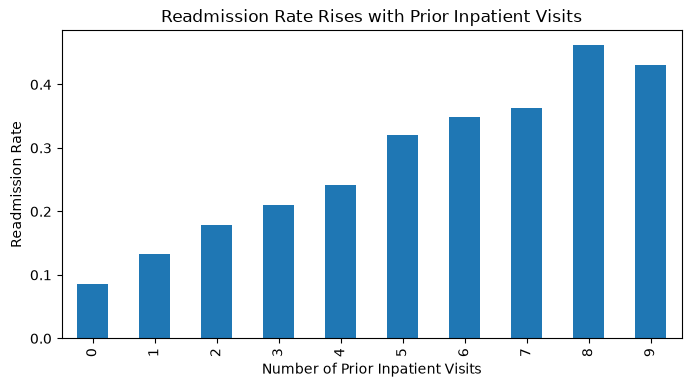

In [20]:
readmit_by_inpatient.head(10).plot(kind='bar', figsize=(8,4))
plt.xlabel('Number of Prior Inpatient Visits')
plt.ylabel('Readmission Rate')
plt.title('Readmission Rate Rises with Prior Inpatient Visits')
plt.show()

**Finding:** readmission rate at 0 prior inpatient visits is ~8.6%, rising steadily to ~46% at 8 prior visits (dropping slightly at 9, likely due to a small sample size in that group). This strongly confirms `number_inpatient` as a powerful signal, consistent with literature, and likely to be one of the most important features when we get to feature importance in modeling.

## 7. Age, Length of Stay, and Medication Count
Checking three more features named explicitly in the project spec. Age is converted to an ordered category first; it's currently sorted alphabetically by coincidence (all bins start with one digit), so making the order explicit avoids relying on that coincidence.

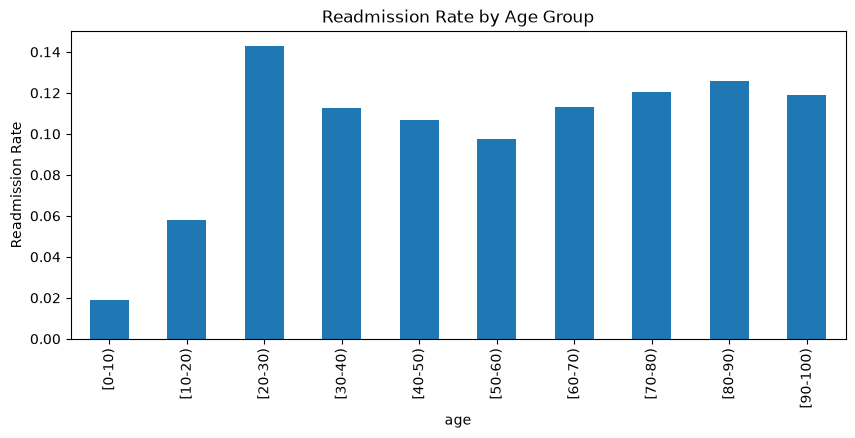

In [21]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df_clean['age'] = pd.Categorical(df_clean['age'], categories=age_order, ordered=True)

df_clean.groupby('age')['readmitted_binary'].mean().plot(kind='bar', figsize=(10,4))
plt.title('Readmission Rate by Age Group')
plt.ylabel('Readmission Rate')
plt.show()

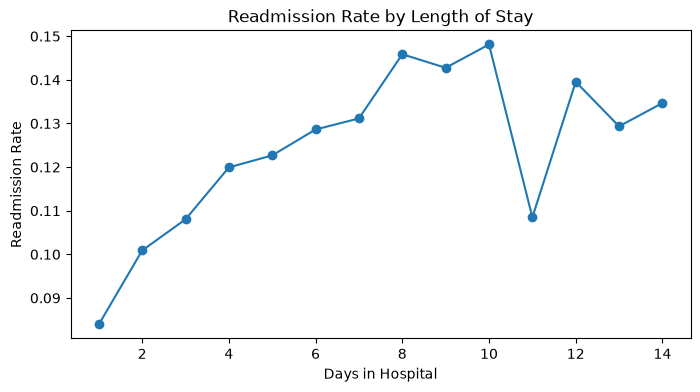

In [22]:
df_clean.groupby('time_in_hospital')['readmitted_binary'].mean().plot(kind='line', marker='o', figsize=(8,4))
plt.title('Readmission Rate by Length of Stay')
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate')
plt.show()

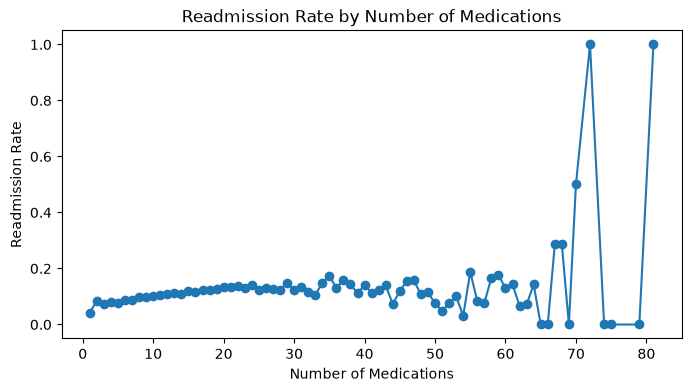

In [23]:
df_clean.groupby('num_medications')['readmitted_binary'].mean().plot(kind='line', marker='o', figsize=(8,4))
plt.title('Readmission Rate by Number of Medications')
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate')
plt.show()

**Finding - Age:** Readmission rate does not rise cleanly with age. The youngest group ([0-10)) has the lowest rate (~2%), but the [20-30) group unexpectedly shows the highest rate of any age bracket (~14.3%) higher than any elderly group. Rates dip through middle age ([40-60): ~10-11%) before climbing again for older patients (~12-13% for 70+). The [20-30) spike is likely inflated by a much smaller sample size in that bracket (diabetes-related hospitalization is far less common in young adults), so this finding should be treated as noisy rather than a strong signal.

**Finding - Length of Stay:** A real upward trend: readmission rate rises steadily from ~8.4% at 1 day to ~14-15% around 8-10 days, consistent with longer stays reflecting sicker or more complex patients; past day 10, the line becomes noisy (e.g. a drop at day 11, spike at day 12), which reflects the much smaller number of patients with very long stays (11-14 days), making those individual rates less statistically reliable.

**Finding - Number of Medications:** Roughly flat and weak for 1-60 medications (readmission rate hovers around 0.10-0.15), suggesting only a mild relationship in the range where most patients fall. Beyond ~65 medications, the rate swings wildly between 0.0 and 1.0 this is a small-sample artifact, not a real trend: almost no patients are prescribed that many distinct medications, so a group of 1-2 patients produces an all-or-nothing readmission rate. This instability should be noted so it isn't mistaken for a genuine pattern later during feature engineering or modeling.

**Overall:** unlike `number_inpatient` (Block 6), none of these three features show as strong or as clean a relationship with readmission. Age and length of stay show mild, partially noisy trends; number of medications is essentially flat except for an unreliable tail caused by tiny sample sizes. This is itself a useful finding, not every feature needs to be a strong predictor to be worth reporting, and it helps set expectations for which features will likely dominate later in feature importance.

## 8. Diagnosis Codes - Raw Glance

The `diag_1`, `diag_2`, and `diag_3` columns hold the patient's primary and secondary diagnoses, coded using **ICD-9**, a standardized numeric system used across US hospitals to classify diseases and medical conditions. This is a completely different coding system from the admission/discharge codes we handled earlier (those came from `IDs_mapping.csv`), ICD-9 codes are medical diagnosis codes, not administrative ones.

Each code is just a number (or number with a decimal, like `250.83`), and different ranges of numbers correspond to different disease categories.. for example, codes in the 390-459 range represent circulatory diseases, and 250.xx specifically represents diabetes. There is no lookup file bundled with this dataset for ICD-9, this is a globally standardized medical coding system, not something specific to this dataset.

**Why this is just a "glance" and not the real analysis:** with 848 distinct raw values in `diag_1` alone, looking at bare numbers won't tell us much on its own, a code like `428` means nothing to a human reader without knowing it maps to "heart failure." Grouping these hundreds of raw codes into a handful of broad, human-readable categories (Circulatory, Respiratory, Diabetes, Digestive, etc.) is planned for the Feature Engineering stage, using the same category ranges established in the original research paper behind this dataset.

**What we're doing here instead:** simply checking which raw codes appear most frequently, as a sanity check before that grouping work , so we know roughly what we're working with and can confirm the grouping step makes sense once we get there.

In [24]:
df_clean['diag_1'].value_counts().head(15)

diag_1
428      6663
414      6550
786      4015
410      3448
486      3383
427      2720
491      2240
715      2147
682      2029
780      2004
996      1937
434      1930
276      1839
250.8    1655
599      1564
Name: count, dtype: int64

**Finding:** the most frequent primary diagnosis codes are dominated by circulatory and cardiac conditions , 428 (heart failure, 6,663 cases), 414 (chronic ischemic heart disease, 6,550), 410 (heart attack, 3,448), and 427 (irregular heartbeat, 2,720) all appear in the top codes. Respiratory issues (786 - respiratory symptoms, 486 - pneumonia, 491 - chronic bronchitis) and diabetes itself (250.8, 1,655 cases) also appear, but notably diabetes is not the single most common primary diagnosis ,consistent with the fact that diabetic patients are frequently hospitalized primarily for cardiovascular complications, with diabetes recorded as a secondary condition. This matches the pattern reported in the original research paper, where circulatory diseases were the largest primary diagnosis category overall (~30.6%). 
Full category-level readmission-rate analysis is deferred to after ICD-9 grouping in Feature Engineering.

## EDA Summary = Key Decisions Going Into Feature Engineering
1. `weight` (~97% missing, not random , under-recorded field prior to 2009 HITECH legislation): kept as a "Missing" category rather than dropped, since it's still available if we want to test whether missingness itself is predictive.
2. `payer_code` / `medical_specialty`: also heavily missing (39.6% / 49.1%) , kept as "Missing" category rather than dropped, since absence may itself be informative (e.g. no medical_specialty listed could correlate with different admission patterns).
3. Removed 2,423 expired/hospice discharge rows before computing target distribution , order matters here, since including them would understate the true readmission rate (expired patients can never be "readmitted").
4. 4,680 rows had unknown/not-mapped discharge codes (18, 25, 26) , relabeled as "Missing" for consistency with how other missing data was handled, rather than left as meaningless separate numeric categories.
5. Final target imbalance: 11.39% positive class (<30-day readmission), recomputed after filtering , confirms class imbalance, so recall will be prioritized over accuracy going forward.
6. 69,990 unique patients across 99,343 encounters (avg. 1.42 encounters/patient) , train/test split must be done at the patient level to avoid data leakage.
7. `number_inpatient` confirmed as a strong predictor , readmission rate rises from 8.6% (0 prior visits) to ~46% (8 prior visits), a clear and consistent upward trend.
8. Age shows a mild, somewhat noisy relationship (highest in [20-30), likely due to small sample size in that bracket); length of stay shows a real but weaker upward trend (8.4% → ~15% from 1 to 10 days); number of medications is largely flat (~0.10-0.15) with an unreliable noisy tail past 65 medications due to tiny sample sizes there.
9. Diagnosis category analysis deferred to post-feature-engineering , raw code glance showed circulatory/cardiac diagnoses (heart failure, ischemic heart disease, heart attack) as the most frequent primary diagnoses, even more common than diabetes itself as a primary code, consistent with the original research paper's findings.

## Feature Engineering - 1. ICD-9 Diagnosis Grouping

Grouping diag_1/2/3 into ~9 broad categories per Strack et al. (2014), Table 2, for comparability with the published research.

Two quirks handled explicitly:
1. V-codes (supplemental classification) AND E-codes (external causes) both fold into 'Other' per the paper's Table 2 , they're listed as a single combined "E–V" line item there, not split into separate categories.
2. Missing diag_2/diag_3 values map to 'Missing', not silently to 'Other'.

Note: the 250–251 diabetes carve-out and the 785/786/787/788 symptom-code additions are this paper's specific modeling choices, not universal ICD-9 chapter boundaries.

### Reference: ICD-9 Primary Diagnosis Groupings (Strack et al., 2014)

The table below is reproduced from the original research paper behind this dataset (Strack et al., 2014, Table 2). It shows how the paper grouped raw ICD-9 diagnosis codes into 9 broad clinical categories, along with how common each category was in their final analysis dataset (69,984 encounters). Categories covering less than 3.5% of encounters were folded into an "Other" bucket by the paper's authors. This is the same grouping logic used in `group_diagnosis()` above...

| Group Name | ICD-9 Codes | % of Encounters (paper) | Description |
|---|---|---|---|
| Circulatory | 390–459, 785 | 30.6% | Diseases of the circulatory system |
| Respiratory | 460–519, 786 | 13.6% | Diseases of the respiratory system |
| Digestive | 520–579, 787 | 9.3% | Diseases of the digestive system |
| Diabetes | 250.xx | 8.2% | Diabetes mellitus |
| Injury | 800–999 | 6.7% | Injury and poisoning |
| Musculoskeletal | 710–739 | 5.8% | Diseases of the musculoskeletal system and connective tissue |
| Genitourinary | 580–629, 788 | 4.9% | Diseases of the genitourinary system |
| Neoplasms | 140–239 | 3.6% | Neoplasms (tumors) |
| Other | 780, 781, 784, 790–799 | 3.1% | Other symptoms, signs, and ill-defined conditions |
| Other | 240–279, without 250 | 2.6% | Endocrine, nutritional, metabolic diseases and immunity disorders (excluding diabetes) |
| Other | 680–709, 782 | 2.6% | Diseases of the skin and subcutaneous tissue |
| Other | 001–139 | 2.4% | Infectious and parasitic diseases |
| Other | 290–319 | 2.2% | Mental disorders |
| Other | E–V | 1.3% | External causes of injury and supplemental classification |
| Other | 280–289 | 0.9% | Diseases of the blood and blood-forming organs |
| Other | 320–359 | 0.9% | Diseases of the nervous system |
| Other | 630–679 | 0.8% | Complications of pregnancy, childbirth, and the puerperium |
| Other | 360–389 | 0.3% | Diseases of the sense organs |
| Other | 740–759 | 0.1% | Congenital anomalies |

**Note:** the paper's "Other" category is actually a merge of many smaller sub-ranges (each individually under 3.5% of encounters), listed separately above for transparency. Our `group_diagnosis()` function collapses all of these into a single `'Other'` bucket directly, rather than tracking each sub-range individually , functionally equivalent, just less granular record-keeping.

Also note: the 785/786/787/788 single-code additions and the 250.xx diabetes carve-out are this paper's specific modeling choices, not standard universal ICD-9 chapter boundaries , worth remembering if you ever compare against a different source's ICD-9 groupings.

In [25]:
def group_diagnosis(code):
    """
    Groups a raw ICD-9 diagnosis code into one of 9 broad clinical categories,
    following Strack et al. (2014), Table 2.
    """
    if pd.isna(code):
        return 'Missing'
    
    code = str(code).strip()
    
    # Both V-codes and E-codes fold into 'Other' per the paper's Table 2
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    
    try:
        code_num = float(code)
    except ValueError:
        return 'Other'  # catch-all safety net
    
    if 250 <= code_num < 251:
        return 'Diabetes'
    if (390 <= code_num <= 459) or code_num == 785:
        return 'Circulatory'
    if (460 <= code_num <= 519) or code_num == 786:
        return 'Respiratory'
    if (520 <= code_num <= 579) or code_num == 787:
        return 'Digestive'
    if 800 <= code_num <= 999:
        return 'Injury'
    if 710 <= code_num <= 739:
        return 'Musculoskeletal'
    if (580 <= code_num <= 629) or code_num == 788:
        return 'Genitourinary'
    if 140 <= code_num <= 239:
        return 'Neoplasms'
    
    return 'Other'

In [26]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col + '_group'] = df_clean[col].apply(group_diagnosis)

# Also clean the raw diag columns themselves, not just the grouped versions,
# so no nulls linger in the original diagnosis fields either
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col] = df_clean[col].fillna('Missing')

for col in ['diag_1_group', 'diag_2_group', 'diag_3_group']:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


diag_1_group:
diag_1_group
Circulatory        29681
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6853
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Missing               20
Name: count, dtype: int64

diag_2_group:
diag_2_group
Circulatory        31158
Other              26027
Diabetes           12705
Respiratory        10390
Genitourinary       8147
Digestive           4088
Injury              2385
Neoplasms           2326
Musculoskeletal     1761
Missing              356
Name: count, dtype: int64

diag_3_group:
diag_3_group
Circulatory        29600
Other              28589
Diabetes           16979
Respiratory         7005
Genitourinary       6436
Digestive           3857
Injury              1898
Musculoskeletal     1898
Neoplasms           1662
Missing             1419
Name: count, dtype: int64


In [27]:
other_examples = df_clean.loc[df_clean['diag_1_group'] == 'Other', 'diag_1'].value_counts().head(10)
print(other_examples)

diag_1
682    2029
780    2004
276    1839
38     1497
V57    1200
296     895
789     560
8       504
295     447
278     378
Name: count, dtype: int64


**Finding:** diag_1 groups closely match the original paper's published percentages , Circulatory is the largest group at 29.9% (paper: 30.6%), followed by Other (17.9%), Respiratory (14.0%), Digestive (9.4%), and Diabetes (8.7%, paper: 8.2%). This close alignment validates the grouping function is working correctly, consistent with using the same category ranges as the source paper.

Spot-checking the 'Other' bucket (codes like 682, 780, 276, 38, V57, 296) confirms these are genuinely codes outside the 9 defined ranges , skin conditions, ill-defined symptoms, non-diabetes endocrine disorders, infectious diseases, mental disorders, and V-codes , not a mapping bug.

Only 20 rows (0.02%) came back as 'Missing' for diag_1, expected since diag_1 (primary diagnosis) is required for essentially every encounter, unlike diag_2/diag_3 which show meaningfully more Missing values (diag_2 shows 1,419+ Missing, consistent with not every encounter having a secondary/tertiary diagnosis logged).

diag_2 groups show a different distribution than diag_1 , Diabetes jumps to 12,705 cases (vs. 8,661 in diag_1), since diabetes is frequently recorded as a secondary rather than primary diagnosis, matching our earlier finding from the raw diagnosis code glance in EDA.

## Feature Engineering - 2. Decoding admission_type_id, discharge_disposition_id, admission_source_id

These are numeric IDs that map to human-readable labels. Rather than parsing a stacked
CSV file by row position (fragile , breaks silently if formatting shifts), we define
the three lookup tables directly, then merge them onto our main data.

Ambiguous/uninformative labels ("Not Available", "Unknown/Invalid", "NULL", "Not Mapped")
are folded into "Missing" for consistency with how we handled other missing data earlier.

These are numeric IDs joined against IDS_mapping.csv. Two problems to solve, not one:
1. IDS_mapping.csv stacks THREE separate lookup tables in one file (admission_type, discharge_disposition, admission_source), typically separated by blank rows — we need to split it into three clean dataframes before joining anything.
2. The mapping file itself has "Not Available," "Unknown/Invalid," "NULL," and "Not Mapped" as *labels* — these are semantically missing even though they have a valid-looking numeric code. Decision: fold these into 'Missing' after the join, don't let them survive as their own noisy categories.

next cell: load and dynamically split the stacked file

In [28]:
ids_raw = pd.read_csv('C:\\Users\\yomna\\Desktop\\readmission-project\\data\\ids_mapping.csv', header=None, skip_blank_lines=False)
# ids_raw has two generic columns from the first header row: 'admission_type_id', 'description'
# The other two tables' headers appear as data rows further down — we detect them by name.

section_headers = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
first_col = ids_raw.columns[0]  # 'admission_type_id'

# Find the row indices where each section's header appears (as data) or is the actual column name
header_positions = {}
for i, val in ids_raw[first_col].items():
    if str(val) in section_headers:
        header_positions[str(val)] = i

# The first section starts at row 0 (its header became the actual column names)
header_positions[first_col] = -1  # marks "starts from row 0"

# Sort sections by their starting row
sorted_sections = sorted(header_positions.items(), key=lambda x: x[1])

tables = {}
for idx, (section_name, start_row) in enumerate(sorted_sections):
    data_start = start_row + 1
    data_end = sorted_sections[idx + 1][1] if idx + 1 < len(sorted_sections) else len(ids_raw)
    
    section_df = ids_raw.iloc[data_start:data_end].copy()
    section_df.columns = [section_name, 'description']
    
    # Drop fully blank separator rows
    section_df = section_df.dropna(how='all')
    
    # Convert id column to numeric, dropping any leftover non-numeric junk rows
    section_df[section_name] = pd.to_numeric(section_df[section_name], errors='coerce')
    section_df = section_df.dropna(subset=[section_name])
    section_df[section_name] = section_df[section_name].astype(int)
    
    tables[section_name] = section_df.reset_index(drop=True)

admission_type_map = tables['admission_type_id']
discharge_map = tables['discharge_disposition_id']
admission_source_map = tables['admission_source_id']

print(admission_type_map)
print(discharge_map)
print(admission_source_map)

   admission_type_id    description
0                  1      Emergency
1                  2         Urgent
2                  3       Elective
3                  4        Newborn
4                  5  Not Available
5                  6            NaN
6                  7  Trauma Center
7                  8     Not Mapped
    discharge_disposition_id  \
0                          1   
1                          2   
2                          3   
3                          4   
4                          5   
5                          6   
6                          7   
7                          8   
8                          9   
9                         10   
10                        11   
11                        12   
12                        13   
13                        14   
14                        15   
15                        16   
16                        17   
17                        18   
18                        19   
19                        20   
20  

next cell: normalize description text (strip whitespace/trailing periods, handle real NaNs)

In [29]:
for table in [admission_type_map, discharge_map, admission_source_map]:
    table['description'] = table['description'].astype(str).str.strip().str.rstrip('.')
    table.loc[table['description'].isin(['nan', 'None']), 'description'] = np.nan

next: match dtypes and merge

In [30]:
discharge_map['discharge_disposition_id'] = discharge_map['discharge_disposition_id'].astype(
    df_clean['discharge_disposition_id'].dtype
)
admission_type_map['admission_type_id'] = admission_type_map['admission_type_id'].astype(
    df_clean['admission_type_id'].dtype
)
admission_source_map['admission_source_id'] = admission_source_map['admission_source_id'].astype(
    df_clean['admission_source_id'].dtype
)

df_clean = df_clean.merge(admission_type_map, on='admission_type_id', how='left')
df_clean = df_clean.rename(columns={'description': 'admission_type_desc'})

df_clean = df_clean.merge(discharge_map, on='discharge_disposition_id', how='left')
df_clean = df_clean.rename(columns={'description': 'discharge_disposition_desc'})

df_clean = df_clean.merge(admission_source_map, on='admission_source_id', how='left')
df_clean = df_clean.rename(columns={'description': 'admission_source_desc'})

next: fold ambiguous labels AND real NaNs into 'Missing'

In [31]:
missing_labels = ['Not Available', 'Unknown/Invalid', 'Not Mapped']  # 'NULL' handled separately below

for col in ['admission_type_desc', 'discharge_disposition_desc', 'admission_source_desc']:
    df_clean[col] = df_clean[col].replace('NULL', np.nan)  # string 'NULL' from earlier data quirks, if any
    df_clean.loc[df_clean[col].isin(missing_labels), col] = 'Missing'
    df_clean[col] = df_clean[col].fillna('Missing')  # catches real NaNs (id=6, 18, 17) and unmatched merges

thennn: sanity check

In [32]:
print("Row count:", len(df_clean))
for col in ['admission_type_desc', 'discharge_disposition_desc', 'admission_source_desc']:
    print(col, "- any remaining nulls:", df_clean[col].isnull().sum())

Row count: 99343
admission_type_desc - any remaining nulls: 0
discharge_disposition_desc - any remaining nulls: 0
admission_source_desc - any remaining nulls: 0


## Feature Engineering - Part 2 Findings: Decoding Admission/Discharge IDs
 
**The problem:** the dataset has three columns that are just numbers;
`admission_type_id`, `discharge_disposition_id`, `admission_source_id`. A number like
`discharge_disposition_id = 11` means nothing to a human reader or to anyone reviewing
this analysis later; you need to know it actually means "Expired." The lookup file
(`IDS_mapping.csv`) has those translations, but it's awkwardly structured: three separate
mini-tables squashed into one CSV, stacked on top of each other rather than as three clean
files. The parsing code correctly detects where one table ends and the next begins by
scanning for the header names, rather than assuming fixed row numbers; which matters,
because if anyone edits that CSV later (adds a row, a blank line), a row-number-based
approach silently breaks and gives wrong labels with no error. This version can't fail like that.
 
### What i found
 
**Admission type** (why the patient came in); mostly straightforward:
- **Emergency**: 52,371 (52.7%) — over half of all admissions
- **Elective**: 18,668 (18.8%) — planned, scheduled admissions
- **Urgent**: 18,132 (18.3%)
- **Missing**: 10,144 (10.2%); folded from "Not Available" labels
- Trauma Center and Newborn are tiny (18 and 10 rows); essentially irrelevant categories
**Discharge disposition** (where the patient went afterward); heavily dominated by one category:
- **Discharged to home**: 60,234 (60.6%) — the clear majority, the "normal" outcome
- **Discharged/transferred to SNF** (Skilled Nursing Facility): 13,954 (14.0%)
- **Discharged with home health service**: 12,902 (13.0%)
- **Missing**: 4,680 (4.7%)
- Everything else is a long tail of small categories (transfers to other hospitals, rehab
  facilities, "Left AMA," etc.), each under 2% individually
**Admission source** (how the patient entered the hospital); again one category dominates:
- **Emergency Room**: 55,850 (56.2%)
- **Physician Referral**: 29,168 (29.4%)
- **Missing**: 6,854 (6.9%)
- **Transfer from a hospital**: 3,118 (3.1%)
- The rest (clinic referral, SNF transfer, HMO referral, court/law enforcement, various
  birth-related categories) are all small, several with fewer than 20 rows total
### Why this matters???
 
These three variables, in their raw numeric-ID form, would be useless (or actively
misleading) to a model; treating `discharge_disposition_id = 11` and `= 1` as "close in
value" makes no sense, since they're really just labels!!! not a scale. Now that they're
decoded into text categories, they can be one-hot encoded meaningfully laterb in the pre-processing part .
 
Also note: each variable has **one dominant category** holding roughly **half or more** of
all rows (Emergency admission type, Discharged-to-home disposition, ER admission source);
which means these features may not carry huge amounts of information on their own, but
combined with `readmitted` they could still reveal useful patterns (ex. does "Left AMA"
correlate with high readmission risk?). **؟؟؟؟؟؟---------- That's a good candidate for the next EDA step: cross-tabulating these three decoded columns against the target variable??????????? ----------------**
 

## Feature Engineering — 3. Medication Columns

23 individual drug columns, each with values Up/Down/Steady/No. Two tasks:
1. Identify near-constant columns (e.g. examide, citoglipton are almost always "No") — these add near-zero signal and are candidates to drop.
2. Build a summary feature: total number of medications that had a dosage change (Up or Down) per encounter — condenses 23 sparse columns into one meaningful number.

next: near-constant check

In [33]:
med_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
               'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
               'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
               'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
               'glipizide-metformin', 'glimepiride-pioglitazone',
               'metformin-rosiglitazone', 'metformin-pioglitazone']

for col in med_columns:
    top_value_pct = df_clean[col].value_counts(normalize=True).max() * 100
    print(f"{col}: {top_value_pct:.2f}% single value")

metformin: 80.02% single value
repaglinide: 98.47% single value
nateglinide: 99.31% single value
chlorpropamide: 99.91% single value
glimepiride: 94.84% single value
acetohexamide: 100.00% single value
glipizide: 87.39% single value
glyburide: 89.41% single value
tolbutamide: 99.98% single value
pioglitazone: 92.70% single value
rosiglitazone: 93.65% single value
acarbose: 99.69% single value
miglitol: 99.96% single value
troglitazone: 100.00% single value
tolazamide: 99.96% single value
examide: 100.00% single value
citoglipton: 100.00% single value
insulin: 46.69% single value
glyburide-metformin: 99.30% single value
glipizide-metformin: 99.99% single value
glimepiride-pioglitazone: 100.00% single value
metformin-rosiglitazone: 100.00% single value
metformin-pioglitazone: 100.00% single value


next: flag near-constant columns (>99% one value)

In [34]:
near_constant_cols = [col for col in med_columns 
                       if df_clean[col].value_counts(normalize=True).max() > 0.99]
print("Near-constant columns (candidates to drop):", near_constant_cols)

Near-constant columns (candidates to drop): ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


next: build `num_meds_changed` (before dropping anything, so nothing gets lost)

In [35]:
df_clean['num_meds_changed'] = df_clean[med_columns].apply(
    lambda row: sum(1 for val in row if val in ['Up', 'Down']), axis=1
)

df_clean['num_meds_changed'].value_counts().sort_index()

num_meds_changed
0    72323
1    25609
2     1299
3      107
4        5
Name: count, dtype: int64

quick preview VS. target

In [36]:
df_clean.groupby('num_meds_changed')['readmitted_binary'].mean()

num_meds_changed
0    0.106536
1    0.134093
2    0.122402
3    0.149533
4    0.000000
Name: readmitted_binary, dtype: float64

next: drop near-constant columns (after building the summary feature)

In [37]:
df_clean = df_clean.drop(columns=near_constant_cols)
print(f"Dropped {len(near_constant_cols)} near-constant medication columns")

Dropped 15 near-constant medication columns


### What this block is actually doing???

This dataset records **23 separate diabetes medications** as individual columns (metformin, insulin, glipizide, etc.). For each one, the value tells you what happened to that specific drug during the hospital visit: was the dosage increased ("Up"), decreased ("Down"), left the same ("Steady"), or was the patient not on it at all ("No").

Having 23 separate columns like this creates two problems:

1. **Most of these drugs are barely ever prescribed.** If a column shows "No" for 99%+ of patients, it's not giving a model any way to tell one patient apart from another ; everyone looks the same on that column, so it carries almost no useful information, while still adding complexity (more columns = more noise, more risk of overfitting).

2. **23 columns is a lot to feed into a model as-is**, especially when most of the signal is concentrated in just a few of them (like insulin, which varies a lot). It's cleaner to reduce this down rather than throw all 23 in raw.

So this block does two things to solve that:

- **Finds and removes the "dead weight" columns** ; the ones that are almost always the same value and therefore not useful.
- **Builds one new summary feature, `num_meds_changed`** ; instead of 23 separate Up/Down/Steady/No columns, this is a single number per patient: how many of their medications were actually changed (Up or Down) during this hospital stay. The idea is that *how much a doctor adjusted a patient's diabetes medication* might itself be a meaningful signal for readmission risk ; a patient whose treatment needed a lot of adjusting might be harder to stabilize than one who didn't need any changes.

In short: im trading 23 messy, mostly-empty columns for a smaller, cleaner set ; a few individual drug columns that actually vary (kept), and one new combined number that captures the overall "how much did treatment change" signal (built).

**Finding - near-constant columns:** 15 of the 23 medication columns were flagged as near-constant (over 99% of patients had the exact same value, almost always "No" ; meaning the drug was essentially never prescribed or never changed in this dataset): `nateglinide`, `chlorpropamide`, `acetohexamide`, `tolbutamide`, `acarbose`, `miglitol`, `troglitazone`, `tolazamide`, `examide`, `citoglipton`, `glyburide-metformin`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`. These were dropped because a column where almost every patient has the same value gives a model nothing to learn from ; it can't tell readmitted vs. non-readmitted patients apart based on a column that barely varies.

The remaining 8 columns (`metformin`, `repaglinide`, `glimepiride`, `glipizide`, `glyburide`, `pioglitazone`, `rosiglitazone`, `insulin`) were kept, since they show real variation across patients. `insulin` stands out especially ; only 46.7% share the same value, meaning insulin prescriptions/dosage changes vary a lot across patients, making it the most informative individual drug column by far.

**Finding - num_meds_changed:** this new column counts, per patient, how many of the 23 original drug columns had a dosage change (Up or Down) during their visit ; condensing 23 sparse columns into a single number. Most patients (72,323) had 0 medication changes, 25,609 had exactly 1 change, and very few had 2+ (1,299 had 2, only 107 had 3, and 5 had 4).

Readmission rate by number of changes: 0 changes → 10.7%, 1 change → 13.4%, 2 changes → 12.2%, 3 changes → 15.0%, 4 changes → 0% (only 5 patients in this group, so this number is unreliable ; too small a sample to mean anything). Overall, there's a mild upward trend ; more medication changes loosely associates with higher readmission risk — but it's not a strong, clean pattern like `number_inpatient` was. Worth keeping as a feature, but not expected to be a top predictor on its own.

## Feature Engineering — 4. total_prior_visits

number_outpatient, number_emergency, and number_inpatient each count a different type of prior visit in the year before this encounter. From EDA, number_inpatient alone was already a strong predictor; combining all three into **one total** gives a single, cleaner measure of **overall prior** healthcare utilization, useful **alongside** (not instead of) the individual columns.

In [38]:
df_clean['total_prior_visits'] = (
    df_clean['number_outpatient'] + df_clean['number_emergency'] + df_clean['number_inpatient']
)

df_clean['total_prior_visits'].describe()

count    99343.000000
mean         1.198625
std          2.294215
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         80.000000
Name: total_prior_visits, dtype: float64

next: relationship with target

In [39]:
df_clean.groupby('total_prior_visits')['readmitted_binary'].mean().head(15)

total_prior_visits
0     0.083236
1     0.118176
2     0.149800
3     0.157424
4     0.176385
5     0.186841
6     0.238431
7     0.230860
8     0.250460
9     0.278960
10    0.252874
11    0.304878
12    0.266667
13    0.298969
14    0.383721
Name: readmitted_binary, dtype: float64

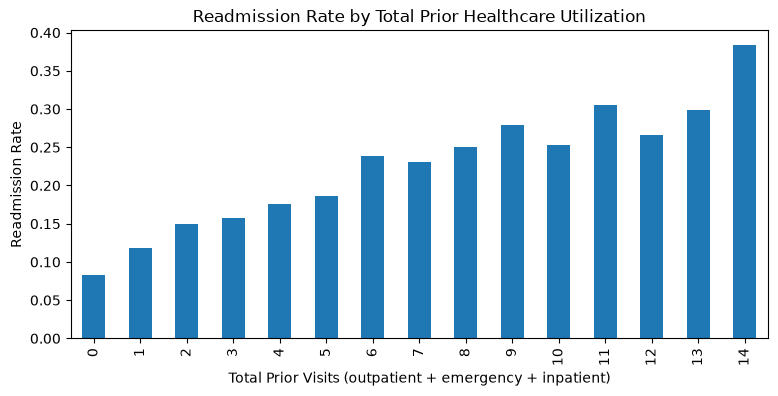

In [40]:
df_clean.groupby('total_prior_visits')['readmitted_binary'].mean().head(15).plot(
    kind='bar', figsize=(9,4)
)
plt.xlabel('Total Prior Visits (outpatient + emergency + inpatient)')
plt.ylabel('Readmission Rate')
plt.title('Readmission Rate by Total Prior Healthcare Utilization')
plt.show()

### What this block is doing??

`number_outpatient`, `number_emergency`, and `number_inpatient` each track a different kind of prior hospital contact in the year before this visit. Instead of looking at them **separately**, this part adds them into one number, `total_prior_visits`, as a simple overall measure of **"how much healthcare has this patient been using lately."** The original three columns are kept too, in case the model finds value in knowing *which type* of visit mattered most.

**Finding:** `total_prior_visits` shows a clear, steady upward trend; readmission rate climbs from 8.3% at 0 prior visits to over 38% at 14 prior visits. This confirms and strengthens the pattern already seen with `number_inpatient` alone in EDA, now capturing outpatient and ER visits too. Most patients (over 75%) have 2 or fewer prior visits, so higher values represent a smaller, higher-risk group. This is one of the strongest single predictors found so far... (still looking for other)

## Feature Engineering — 5. Diabetes-Related Flag

diag_1_group only captures diabetes as the *primary* diagnosis. But diabetes could appear as a **secondary or tertiary diagnosis** too, according to literature; still clinically relevant for a diabetes readmission model, even if it wasn't the main reason for admission. This flag captures diabetes appearing *anywhere* in diag_1/2/3.

To help understand this part more.. `diag_1_group` from Block 1.. That column only tells you the patient's main/primary reason for admission. But your dataset also has `diag_2` and `diag_3`; a secondary and a third diagnosis, ***other health issues the patient had at the same time***, **even if they weren't the main reason for the hospital visit.**

So here's the situation.. a patient could be admitted mainly for a heart problem `(diag_1 = Circulatory)`, but also happen to have diabetes noted as a *secondary9* issue `(diag_2 = Diabetes)`. If you only look at `diag_1_group`, you'd completely ***miss*** the fact that this patient has diabetes at all; even though this whole project is about diabetes patients specifically!!

***What this block does about it??***:

It creates one *new simple column*, `diabetes_related`, that just asks: ***"Does this patient have diabetes mentioned anywhere; as primary, secondary, OR third diagnosis?"*** If yes, mark them as 1. If diabetes doesn't show up in any of the three, mark them as 0.

In [41]:
df_clean['diabetes_related'] = (
    (df_clean['diag_1_group'] == 'Diabetes') |
    (df_clean['diag_2_group'] == 'Diabetes') |
    (df_clean['diag_3_group'] == 'Diabetes')
).astype(int)

df_clean['diabetes_related'].value_counts(normalize=True) * 100

diabetes_related
0    62.086911
1    37.913089
Name: proportion, dtype: float64

In [42]:
df_clean.groupby('diabetes_related')['readmitted_binary'].mean()

diabetes_related
0    0.115988
1    0.110450
Name: readmitted_binary, dtype: float64

**Finding:** 37.9% of encounters have ***diabetes*** mentioned somewhere in `diag_1/2/3`, compared to only *8.7%* where diabetes was the ***primary*** diagnosis (from Block 1)!!!. This confirms ***diabetes*** **shows up far more often as a secondary/tertiary condition than as the main reason for admission**; consistent with the EDA finding that most primary diagnoses were actually circulatory/cardiac!

Readmission rate is nearly identical either way: 11.6% for patients **without diabetes** anywhere in their diagnoses vs. 11.0% for **those with it**; a very small difference, essentially flat. So while `diabetes_related` is useful for identifying which patients are actually diabetic (useful for filtering/context), it doesn't appear to be a strong standalone predictor of readmission on its own.

##### whether or not a patient has diabetes mentioned in their diagnoses doesn't really change how likely they are to be readmitted... it doesn't appear to be a strong standalone predictor of readmission on its own. 

##### This just means: this feature, by itself, won't help a model tell apart "will be readmitted" vs "won't be readmitted" very well; because both groups behave almost the same. A good predictor should show clearly different readmission rates between its groups (like number_inpatient did). diabetes doesnt!

##### but it can be useful for identifying which patients are actually diabetic (useful for filtering/context)

## Feature Engineering — 6. Dropping encounter_id

encounter_id uniquely identifies a single hospital visit but carries no clinical meaning; unlike patient_nbr, which we still need later to split train/test by patient (avoiding leakage from the same patient appearing in both sets). encounter_id has no such future use, so it's dropped now.

In [43]:
df_clean = df_clean.drop(columns=['encounter_id'])
print("encounter_id dropped. Current shape:", df_clean.shape)

encounter_id dropped. Current shape: (99343, 44)


## Feature Engineering — 7. Formalizing "Missing" Categories

weight, payer_code, and medical_specialty were already decided in EDA as "Missing" category rather than dropped (weight: ~97% missing but potentially informative if missingness itself matters; payer_code/medical_specialty: heavily missing but absence may correlate with admission patterns). This block makes that decision real in code, in one place, rather than leaving it implicit.

In [44]:
for col in ['weight', 'payer_code', 'medical_specialty']:
    df_clean[col] = df_clean[col].fillna('Missing')

# Confirm no NaNs remain in these three columns
for col in ['weight', 'payer_code', 'medical_specialty']:
    print(col, "- remaining nulls:", df_clean[col].isnull().sum())
    print(df_clean[col].value_counts(normalize=True).head(5) * 100)
    print()

weight - remaining nulls: 0
weight
Missing      96.854333
[75-100)      1.320677
[50-75)       0.872734
[100-125)     0.621080
[125-150)     0.143946
Name: proportion, dtype: float64

payer_code - remaining nulls: 0
payer_code
Missing    39.658557
MC         31.540219
HM          6.235970
SP          4.973677
BC          4.631428
Name: proportion, dtype: float64

medical_specialty - remaining nulls: 0
medical_specialty
Missing                   48.937520
InternalMedicine          14.331156
Emergency/Trauma           7.468065
Family/GeneralPractice     7.299961
Cardiology                 5.313912
Name: proportion, dtype: float64



In [45]:
for col in ['weight', 'payer_code', 'medical_specialty']:
    is_missing = (df_clean[col] == 'Missing').astype(int)
    print(col, "readmission rate by missing status:")
    print(df_clean.groupby(is_missing)['readmitted_binary'].mean())
    print()

weight readmission rate by missing status:
weight
0    0.113920
1    0.113887
Name: readmitted_binary, dtype: float64

payer_code readmission rate by missing status:
payer_code
0    0.111903
1    0.116909
Name: readmitted_binary, dtype: float64

medical_specialty readmission rate by missing status:
medical_specialty
0    0.109626
1    0.118336
Name: readmitted_binary, dtype: float64



##### **Finding:** all three columns confirmed with 0 remaining nulls, "Missing" formally encoded... Testing whether missingness itself predicts readmission: none of the three show a meaningful difference; weight (11.39% missing vs. 11.39% not missing), payer_code (11.69% vs. 11.19%), medical_specialty (11.83% vs. 10.96%). All gaps are under 1 percentage point, meaning whether these fields were recorded or not doesn't meaningfully relate to readmission risk on its own. This answers the question raised in EDA: missingness itself isn't a useful signal here, even though we still keep "Missing" as a category rather than dropping these columns.

## Outlier check code 

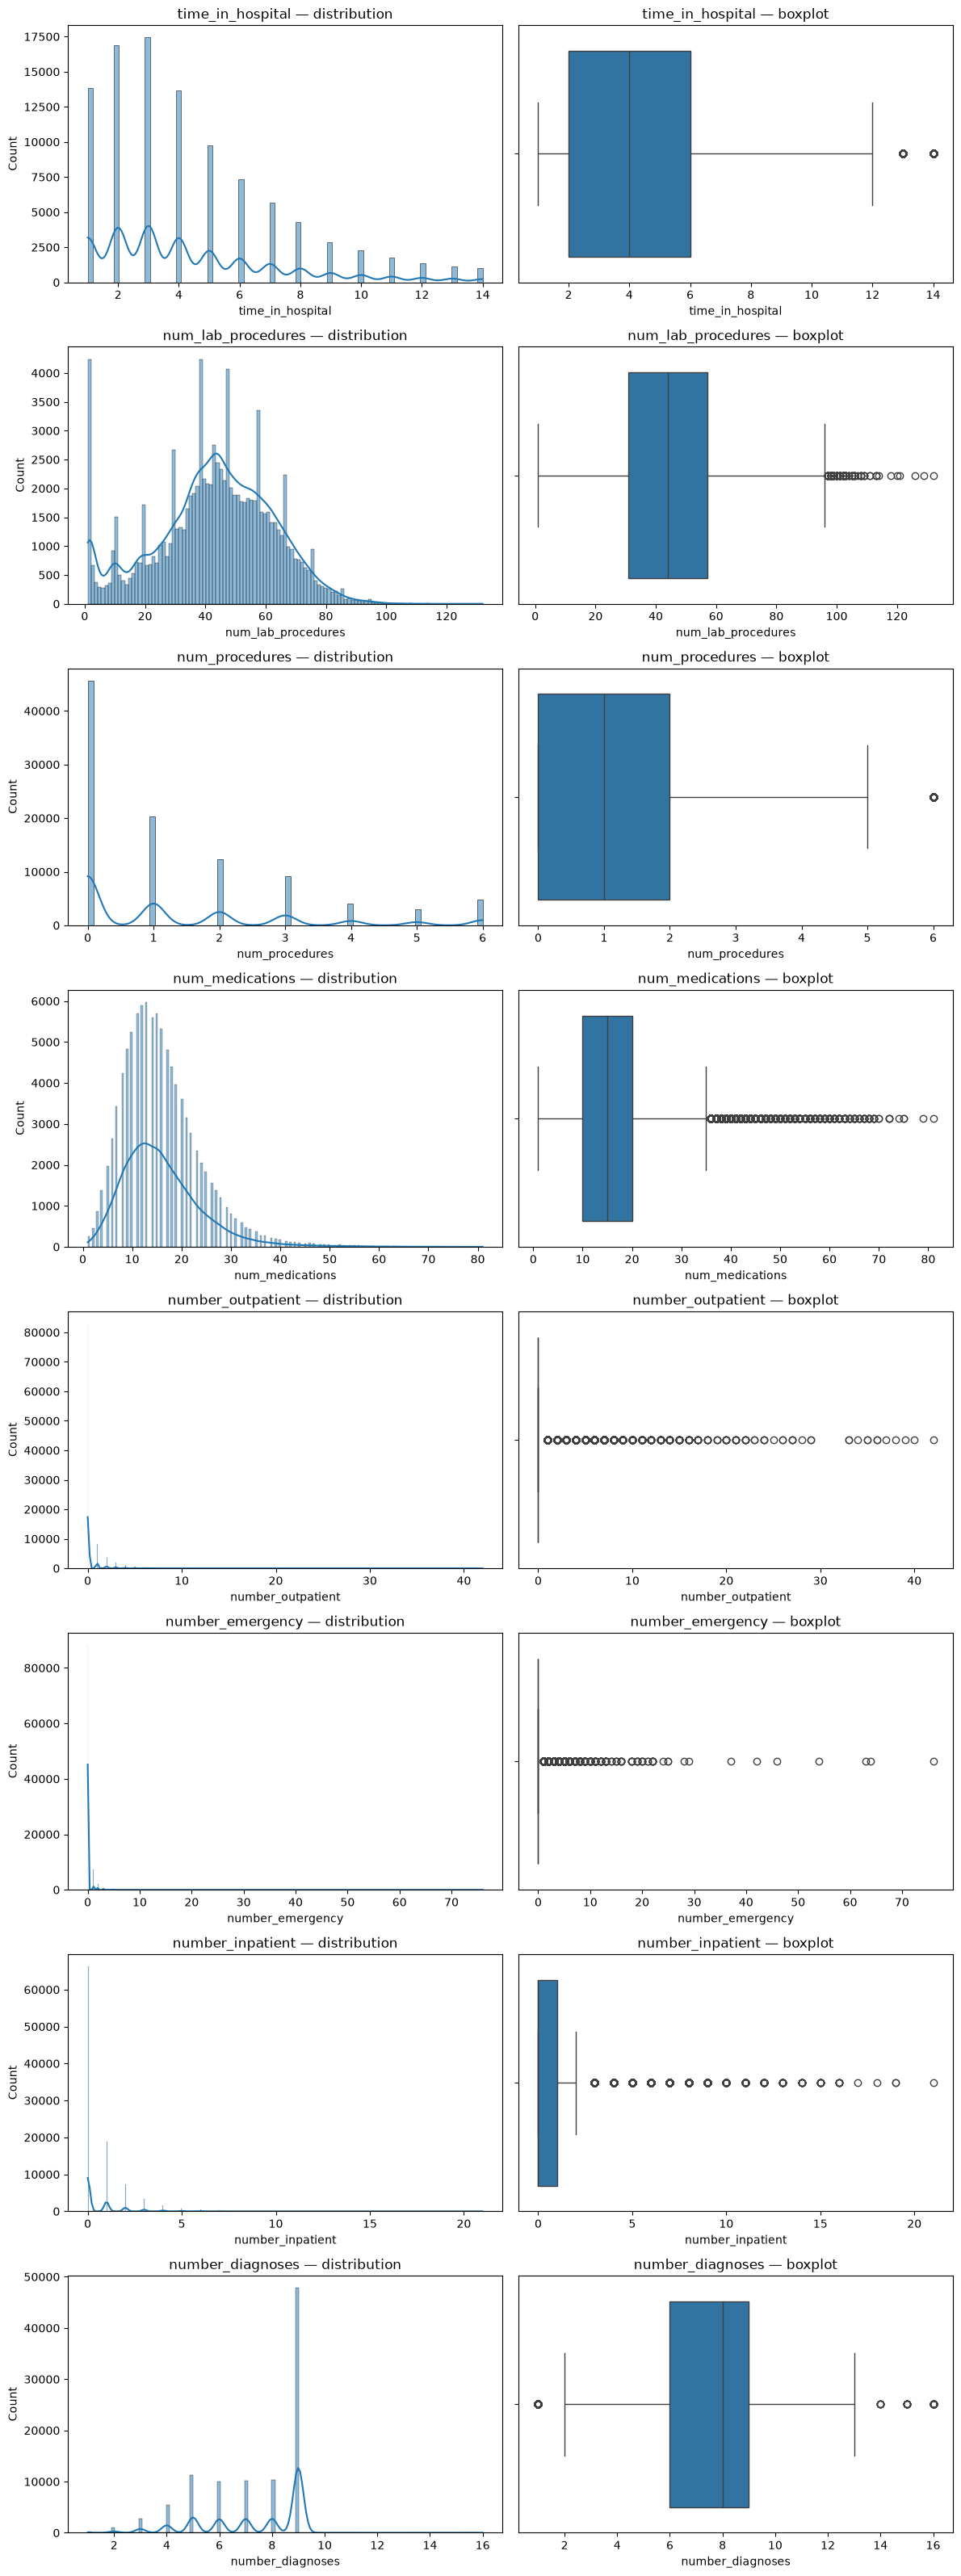

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — distribution')

    sns.boxplot(x=df_clean[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — boxplot')

plt.tight_layout()
plt.show()

virtually identical in shape to your original run

In [47]:
print(df_clean[numeric_cols].describe().T)

                      count       mean        std  min   25%   50%   75%  \
time_in_hospital    99343.0   4.379332   2.968409  1.0   2.0   4.0   6.0   
num_lab_procedures  99343.0  42.906929  19.610032  1.0  31.0  44.0  57.0   
num_procedures      99343.0   1.334236   1.702786  0.0   0.0   1.0   2.0   
num_medications     99343.0  15.979062   8.094909  1.0  10.0  15.0  20.0   
number_outpatient   99343.0   0.369246   1.265142  0.0   0.0   0.0   0.0   
number_emergency    99343.0   0.198444   0.937734  0.0   0.0   0.0   0.0   
number_inpatient    99343.0   0.630935   1.260428  0.0   0.0   0.0   1.0   
number_diagnoses    99343.0   7.401709   1.941013  1.0   6.0   8.0   9.0   

                      max  
time_in_hospital     14.0  
num_lab_procedures  132.0  
num_procedures        6.0  
num_medications      81.0  
number_outpatient    42.0  
number_emergency     76.0  
number_inpatient     21.0  
number_diagnoses     16.0  


#### Readmit-rate check against high-value tails

In [48]:
for col in ['number_outpatient', 'number_emergency', 'number_inpatient']:
    threshold = df_clean[col].quantile(0.99)
    high_group = df_clean[df_clean[col] >= threshold]
    rest = df_clean[df_clean[col] < threshold]

    high_target = high_group['readmitted_binary']
    rest_target = rest['readmitted_binary']

    print(f"--- {col} ---")
    print(f"99th pct threshold: {threshold}")
    print(f"High-value rows: {len(high_group)} | readmit rate: {high_target.mean():.3f}")
    print(f"Rest rows: {len(rest)} | readmit rate: {rest_target.mean():.3f}")
    print()

--- number_outpatient ---
99th pct threshold: 5.0
High-value rows: 1417 | readmit rate: 0.126
Rest rows: 97926 | readmit rate: 0.114

--- number_emergency ---
99th pct threshold: 3.0
High-value rows: 1636 | readmit rate: 0.253
Rest rows: 97707 | readmit rate: 0.112

--- number_inpatient ---
99th pct threshold: 6.0
High-value rows: 1178 | readmit rate: 0.406
Rest rows: 98165 | readmit rate: 0.110



##### ***``Outlier verdict ; number_outpatient, number_emergency, number_inpatient``***: 
All three showed extreme-tail values on boxplots, but cross-checking against readmission rate shows this tail is real signal, not noise... ***Decision: no capping, clipping, or removal.***

## One last sanity check

In [49]:
print("Final shape:", df_clean.shape)
print("\nColumns:", list(df_clean.columns))
print("\nAny remaining nulls:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Final shape: (99343, 44)

Columns: ['patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted', 'readmitted_binary', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'admission_type_desc', 'discharge_disposition_desc', 'admission_source_desc', 'num_meds_changed', 'total_prior_visits', 'diabetes_related']

Any remaining nulls:
Series([], dtype: int64)


##Saving the cleaned data in a new CSV file so that we can use it 

In [50]:
df_clean.to_csv('../data/diabetic_data_engineered.csv', index=False)
print("Saved. Shape:", df_clean.shape)

Saved. Shape: (99343, 44)


## EDA & Feature Engineering - Completed!!
Full exploratory data analysis and feature engineering finished and verified; zero nulls, shape (99343, 44).
Final engineered dataset saved to `data/diabetic_data_engineered.csv`.
Next notebook (`02_preprocessing_modeling.ipynb`) loads this file directly; no need to rerun EDA/Feature Engineering!!